# SpecMap - Hyperspectral Standard Interface

This notebook demonstrates how to interface SpecMap data with standard hyperspectral imaging libraries and formats.

## Overview

SpecMap is specialized for microscale spectroscopic imaging (Raman, FTIR). This notebook shows how to:

1. **Load SpecMap data** into memory
2. **Convert to ENVI format** (the industry standard for hyperspectral data)
3. **Interface with Spectral Python (SPy)** for advanced analysis
4. **Interface with PySptools** for spectral unmixing
5. **Export data** in standard formats

## Hyperspectral Libraries Comparison

| Library | Primary Strength | Best For |
|---------|-----------------|----------|
| **Spectral Python (SPy)** | General HSI Processing | Robust, fast, handles massive cubes |
| **PySptools** | Unmixing/Chemical Mapping | Identifying crystal phases, endmember extraction |
| **PyHAT** | Spectral Libraries/GUI | Reference matching, regression models |
| **SpecMap** | Spectroscopic Imaging | Specialist for Raman/FTIR microscopy |

## Installation

To use this notebook, you need to install the hyperspectral libraries:

```bash
pip install spectral  # Spectral Python (SPy)
pip install pysptools  # For spectral unmixing
```

Optional:
```bash
pip install scikit-image  # For additional image processing
```

## 1. Setup and Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

# Add SpecMap modules to path if needed
# Uncomment if running from a different directory
# sys.path.append('/path/to/SpecMap')

# Import SpecMap modules
import lib9
import deflib1 as deflib
import PMclasslib1 as PMlib

# Import hyperspectral libraries (install with: pip install spectral pysptools)
try:
    import spectral as spy
    import spectral.io.envi as envi
    SPY_AVAILABLE = True
    print("✓ Spectral Python (SPy) loaded successfully")
except ImportError:
    SPY_AVAILABLE = False
    print("⚠ Spectral Python not available. Install with: pip install spectral")

try:
    import pysptools.util as util
    import pysptools.eea as eea  # Endmember Extraction Algorithms
    import pysptools.abundance_maps as amap
    PYSPTOOLS_AVAILABLE = True
    print("✓ PySptools loaded successfully")
except ImportError:
    PYSPTOOLS_AVAILABLE = False
    print("⚠ PySptools not available. Install with: pip install pysptools")

print("\n📊 SpecMap Hyperspectral Standard Interface Ready")

✓ Spectral Python (SPy) loaded successfully
✓ PySptools loaded successfully

📊 SpecMap Hyperspectral Standard Interface Ready


## 2. Load SpecMap Data

First, let's load data using SpecMap's native format.

In [10]:
# Configure data loading parameters
data_folder = "testdatasets/HSI20240903_I01"  # Example dataset
filename_pattern = "HSI20240903_I01_"  # Pattern for spectral files
file_extension = ".txt"  # File extension

# Check if data folder exists
if not os.path.exists(data_folder):
    print(f"⚠ Data folder not found: {data_folder}")
    print("Please update the data_folder variable to point to your spectral data.")
else:
    print(f"✓ Data folder found: {data_folder}")
    files = [f for f in os.listdir(data_folder) if f.endswith(file_extension)]
    print(f"  Found {len(files)} spectral files")

✓ Data folder found: testdatasets/HSI20240903_I01
  Found 11 spectral files


In [26]:
# Load data using SpecMap's XYMap class
# This creates a hyperspectral cube from individual spectral files

# Initialize with default settings
# Note: In notebook environment, we need to handle GUI dependencies explicitly
import tkinter as tk
if not tk._default_root:
    root = tk.Tk()
    root.withdraw()

defaults = deflib.initdefaults()

# XYMap requires a list of full file paths
full_paths = [os.path.join(data_folder, f) for f in files]
full_paths.sort()  # Ensure deterministic order

# Create XYMap instance with correct arguments for headless operation
# XYMap(fnames, cmapframe, specframe, loadbg, linearbg, removecosmics, cosmicthreshold, cosmicpixels, ...)
xymap = lib9.XYMap(
    full_paths,           # fnames: List of file paths to load
    None,                 # cmapframe: specialized GUI frame (None for notebook)
    None,                 # specframe: specialized GUI frame (None for notebook)
    loadbg=False,         # loadeachbg -> loadbg
    linearbg=False,       # No linear background correction
    removecosmics=False,  # No cosmic ray removal (can be enabled)
    cosmicthreshold=20,
    cosmicpixels=3,
    skip_gui_build=True   # Important for notebook execution to skip GUI creation
)

# Load the files
print("Loading spectral data...")
# In recent versions, load_data() handles file loading and initialization
xymap.load_data()

# Create alias for compatibility with rest of notebook (native attribute is 'specs')
xymap.Specdata = xymap.specs

if xymap.Specdata:
    print(f"✓ Loaded {len(xymap.Specdata)} spectra")
    print(f"  Wavelength range: {xymap.WL[0]:.2f} - {xymap.WL[-1]:.2f} nm")
    print(f"  Number of wavelength points: {len(xymap.WL)}")
else:
    print("⚠ No data loaded. Check the file paths and parameters.")

Derivative calculation skipped: Neither 1st nor 2nd derivative requested.
Loading spectral data...
Derivative calculation skipped: Neither 1st nor 2nd derivative requested.
✓ Loaded 11 spectra
  Wavelength range: 458.55 - 740.22 nm
  Number of wavelength points: 1024


In [27]:
# Build the hyperspectral cube (3D array: x, y, wavelength)
print("Building hyperspectral data cube...")

# NOTE: previous call to xymap.SpecdataintoMatrix() removed as it's handled by load_data()
# and calling it again causes warnings about occupied positions.

# Manually construct the HSI cube (3D numpy array) from SpecDataMatrix
# SpecMap native structure is a 2D grid of SpectrumData objects
if hasattr(xymap, 'SpecDataMatrix') and xymap.SpecDataMatrix:
    rows = len(xymap.SpecDataMatrix)
    cols = len(xymap.SpecDataMatrix[0])
    
    # Trace first valid spectrum to get dimensions
    n_bands = 0
    for r in range(rows):
        for c in range(cols):
            obj = xymap.SpecDataMatrix[r][c]
            # Check for valid SpectrumData object (grid may facilitate np.nan for empty pixels)
            if hasattr(obj, 'PLB') and len(obj.PLB) > 0:
                n_bands = len(obj.PLB)
                break
                
    if n_bands > 0:
        # Initialize 3D Cube (Rows, Cols, Bands)
        xymap.HSI = np.zeros((rows, cols, n_bands), dtype=np.float32)
        
        valid_pixels = 0
        for r in range(rows):
            for c in range(cols):
                obj = xymap.SpecDataMatrix[r][c]
                if hasattr(obj, 'PLB') and len(obj.PLB) == n_bands:
                    xymap.HSI[r, c, :] = obj.PLB
                    valid_pixels += 1
                    
        # Alias axes for compatibility with notebook visualization code
        if hasattr(xymap, 'PixAxX'): xymap.xax = xymap.PixAxX
        if hasattr(xymap, 'PixAxY'): xymap.yax = xymap.PixAxY
        
    else:
        print("⚠ Could not detect spectral bands.")
        xymap.HSI = None
else:
    print("⚠ No SpecDataMatrix found. Data loading might have failed.")
    xymap.HSI = None

if hasattr(xymap, 'HSI') and xymap.HSI is not None:
    print(f"✓ Hyperspectral cube created")
    print(f"  Dimensions: {xymap.HSI.shape} (rows × cols × wavelengths)")
    if hasattr(xymap, 'xax') and len(xymap.xax) > 1:
        print(f"  Spatial extent: {xymap.xax[0]:.2f} to {xymap.xax[-1]:.2f} (x), {xymap.yax[0]:.2f} to {xymap.yax[-1]:.2f} (y)")
    print(f"  Data type: {xymap.HSI.dtype}")
else:
    print("⚠ Failed to create hyperspectral cube")

Building hyperspectral data cube...
✓ Hyperspectral cube created
  Dimensions: (1, 11, 1024) (rows × cols × wavelengths)
  Spatial extent: 50.00 to 100.00 (x), 50.00 to 50.00 (y)
  Data type: float32


## 3. Visualize SpecMap Data

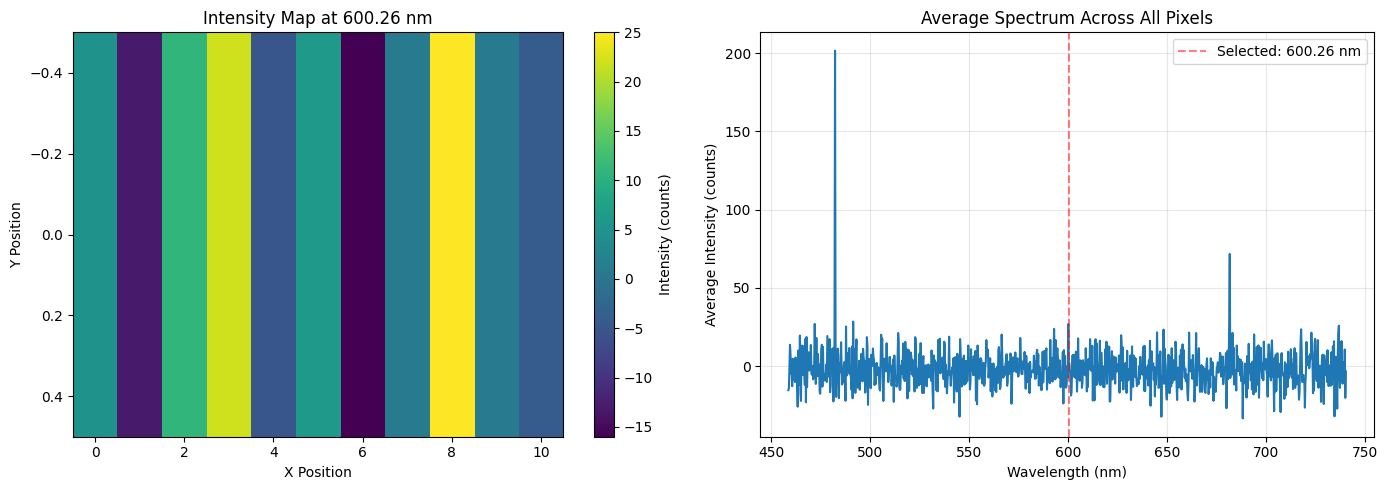


📊 Data Statistics:
  Min intensity: -52.00
  Max intensity: 2202.00
  Mean intensity: -1.81
  Std deviation: 25.90


In [28]:
# Display a single wavelength slice
if hasattr(xymap, 'HSI') and xymap.HSI is not None:
    # Select wavelength index (middle of the spectrum)
    wl_idx = len(xymap.WL) // 2
    selected_wl = xymap.WL[wl_idx]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot single wavelength slice
    im1 = ax1.imshow(xymap.HSI[:, :, wl_idx], cmap='viridis', aspect='auto')
    ax1.set_title(f'Intensity Map at {selected_wl:.2f} nm')
    ax1.set_xlabel('X Position')
    ax1.set_ylabel('Y Position')
    plt.colorbar(im1, ax=ax1, label='Intensity (counts)')
    
    # Plot average spectrum
    avg_spectrum = np.mean(xymap.HSI, axis=(0, 1))
    ax2.plot(xymap.WL, avg_spectrum)
    ax2.axvline(selected_wl, color='r', linestyle='--', alpha=0.5, label=f'Selected: {selected_wl:.2f} nm')
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Average Intensity (counts)')
    ax2.set_title('Average Spectrum Across All Pixels')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Data Statistics:")
    print(f"  Min intensity: {np.min(xymap.HSI):.2f}")
    print(f"  Max intensity: {np.max(xymap.HSI):.2f}")
    print(f"  Mean intensity: {np.mean(xymap.HSI):.2f}")
    print(f"  Std deviation: {np.std(xymap.HSI):.2f}")

## 4. Convert to ENVI Format (Hyperspectral Standard)

ENVI is the industry standard format for hyperspectral data. It consists of:
- A binary file (.img) containing the data cube
- A header file (.hdr) containing metadata

In [31]:
def specmap_to_envi(xymap, output_filename):
    """
    Convert SpecMap hyperspectral data to ENVI format.
    
    Parameters:
    -----------
    xymap : lib9.XYMap
        SpecMap hyperspectral data object
    output_filename : str
        Output filename (without extension)
        
    Returns:
    --------
    tuple : (data_file, header_file) paths
    """
    if not hasattr(xymap, 'HSI') or xymap.HSI is None:
        raise ValueError("No hyperspectral data found in XYMap object")
    
    # Prepare data - ENVI format expects (bands, rows, cols) or (rows, cols, bands)
    # SpecMap uses (rows, cols, bands) - this is BIP (Band Interleaved by Pixel)
    hsi_data = xymap.HSI
    
    # Prepare wavelength list - verify type
    wl_list = []
    if hasattr(xymap, 'WL'):
        if isinstance(xymap.WL, np.ndarray):
            wl_list = xymap.WL.tolist()
        elif isinstance(xymap.WL, list):
            wl_list = xymap.WL
        else:
            # Fallback for unexpected types
            wl_list = list(xymap.WL)
            
    # Create metadata dictionary
    metadata = {
        'lines': hsi_data.shape[0],
        'samples': hsi_data.shape[1],
        'bands': hsi_data.shape[2],
        'header offset': 0,
        'file type': 'ENVI Standard',
        'data type': 4,  # 4 = 32-bit float
        'interleave': 'bip',  # Band Interleaved by Pixel
        'byte order': 0,  # Little endian
        'wavelength': wl_list,
        'wavelength units': 'nm',
        'description': f'SpecMap hyperspectral data cube',
    }
    
    # Add SpecMap metadata if available
    # Check alias compatibility for specs/Specdata
    specs_list = []
    if hasattr(xymap, 'Specdata') and xymap.Specdata:
        specs_list = xymap.Specdata
    elif hasattr(xymap, 'specs') and xymap.specs:
        specs_list = xymap.specs
        
    if specs_list and len(specs_list) > 0:
        first_spec = specs_list[0]
        if hasattr(first_spec, 'data'):
            metadata['specmap metadata'] = str(first_spec.data)
    
    # Write ENVI files
    if SPY_AVAILABLE:
        # Use spectral library if available
        img_file = output_filename + '.img'
        hdr_file = output_filename + '.hdr'
        
        envi.save_image(hdr_file, hsi_data.astype(np.float32), metadata=metadata, force=True)
        print(f"✓ ENVI files created:")
        print(f"  Data: {img_file}")
        print(f"  Header: {hdr_file}")
        return img_file, hdr_file
    else:
        # Manual ENVI file creation if spectral library not available
        img_file = output_filename + '.img'
        hdr_file = output_filename + '.hdr'
        
        # Write binary data
        hsi_data.astype(np.float32).tofile(img_file)
        
        # Write header file
        with open(hdr_file, 'w') as f:
            f.write('ENVI\n')
            for key, value in metadata.items():
                if isinstance(value, list):
                    f.write(f'{key} = {{\n')
                    for i, v in enumerate(value):
                        f.write(f' {v}')
                        if i < len(value) - 1:
                            f.write(',')
                        if (i + 1) % 10 == 0:
                            f.write('\n')
                    f.write('}\n')
                else:
                    f.write(f'{key} = {value}\n')
        
        print(f"✓ ENVI files created (manual):")
        print(f"  Data: {img_file}")
        print(f"  Header: {hdr_file}")
        return img_file, hdr_file

In [32]:
# Convert SpecMap data to ENVI format
if hasattr(xymap, 'HSI') and xymap.HSI is not None:
    output_base = "specmap_export"
    img_file, hdr_file = specmap_to_envi(xymap, output_base)
    print(f"\n💾 ENVI export complete!")

OSError: [Errno 22] Invalid argument: 'C:\\Users\\volib\\Desktop\\Evaluation\\code\\SpecMap\\SpecMap1\\specmap_export.img'

## 5. Interface with Spectral Python (SPy)

Spectral Python is the industry standard for hyperspectral imaging analysis.

✓ Loaded ENVI file with Spectral Python
  Shape: (1, 11, 1024)
  Metadata: dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'byte order', 'wavelength', 'wavelength units', 'specmap metadata'])


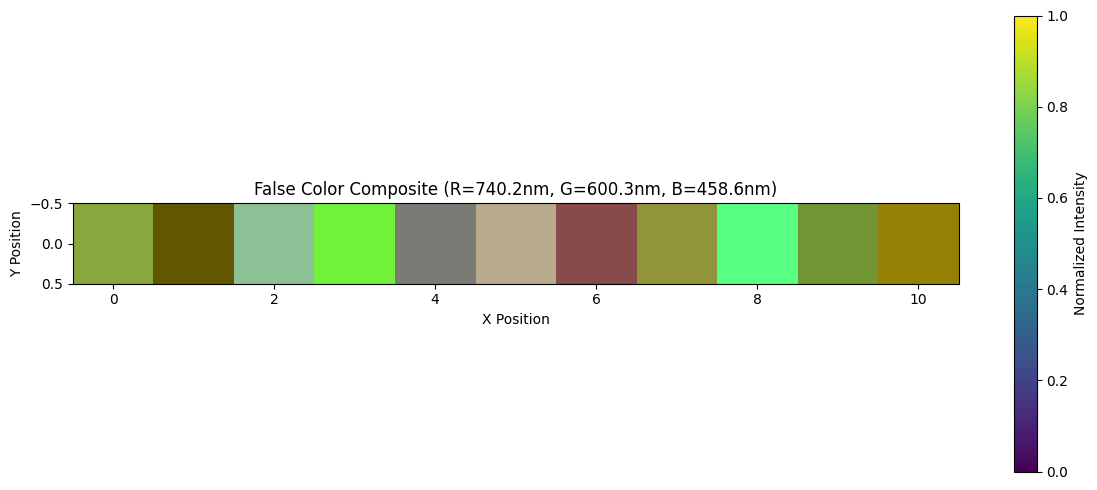


📊 SPy Statistics:
  Mean per band: min=-33.45, max=201.55


In [33]:
if SPY_AVAILABLE and hasattr(xymap, 'HSI') and xymap.HSI is not None:
    # Load ENVI file with SPy
    img = envi.open(hdr_file, img_file)
    print("✓ Loaded ENVI file with Spectral Python")
    print(f"  Shape: {img.shape}")
    print(f"  Metadata: {img.metadata.keys()}")
    
    # View with SPy's imshow
    plt.figure(figsize=(12, 5))
    
    # Display RGB composite (if we have enough bands)
    if img.shape[2] > 50:
        # Select three bands for RGB composite
        r_band = img.shape[2] - 1  # Red: longest wavelength
        g_band = img.shape[2] // 2  # Green: middle wavelength
        b_band = 0  # Blue: shortest wavelength
        
        rgb = np.dstack([
            img[:, :, r_band],
            img[:, :, g_band],
            img[:, :, b_band]
        ])
        
        # Normalize for display
        rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        
        plt.imshow(rgb_norm)
        plt.title(f'False Color Composite (R={xymap.WL[r_band]:.1f}nm, G={xymap.WL[g_band]:.1f}nm, B={xymap.WL[b_band]:.1f}nm)')
        plt.colorbar(label='Normalized Intensity')
    else:
        # Single band display
        plt.imshow(img[:, :, img.shape[2]//2], cmap='viridis')
        plt.title(f'Intensity at {xymap.WL[img.shape[2]//2]:.2f} nm')
        plt.colorbar(label='Intensity')
    
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.tight_layout()
    plt.show()
    
    print("\n📊 SPy Statistics:")
    print(f"  Mean per band: min={np.mean(img[:,:,:], axis=(0,1)).min():.2f}, max={np.mean(img[:,:,:], axis=(0,1)).max():.2f}")
else:
    print("⚠ Spectral Python not available or no data loaded")

## 6. Spectral Analysis with SPy

Perform common hyperspectral analysis operations.

Running K-means clustering...
Iteration 1...  0.Iteration 1...  0.Iteration 1...1 pixels reassigned.
Iteration 2...  0.Iteration 2...  0.Iteration 2...0 pixels reassigned.


spectral:INFO: kmeans terminated with 2 clusters after 1 iterations
INFO:spectral:kmeans terminated with 2 clusters after 1 iterations


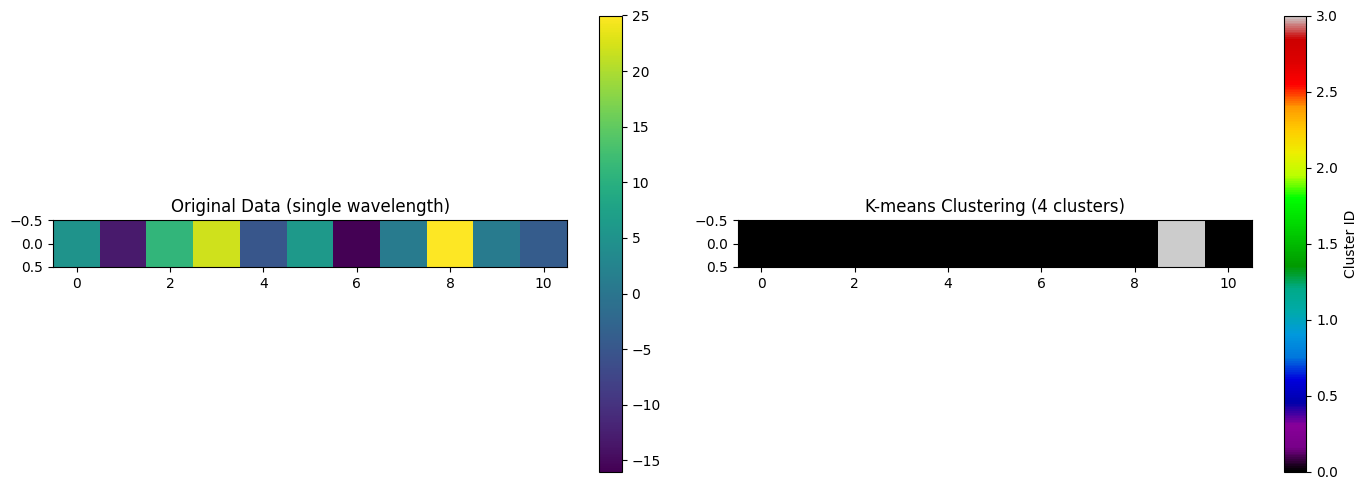

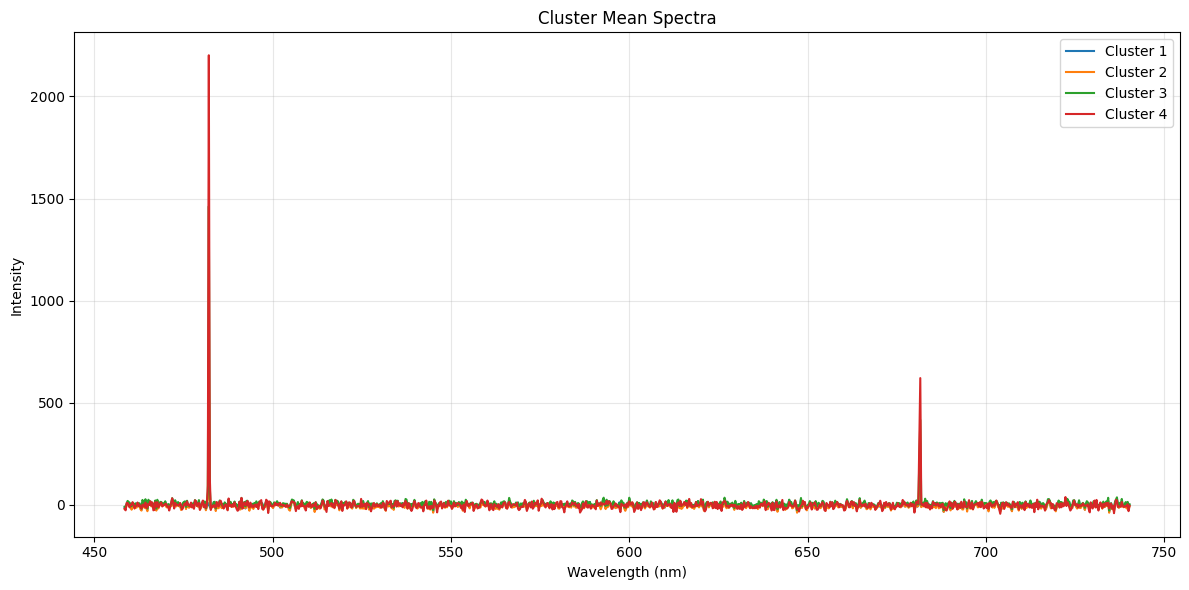


✓ K-means clustering completed
  Number of clusters: 4
  Cluster 1: 10 pixels (90.9%)
  Cluster 2: 0 pixels (0.0%)
  Cluster 3: 0 pixels (0.0%)
  Cluster 4: 1 pixels (9.1%)


In [34]:
if SPY_AVAILABLE and hasattr(xymap, 'HSI') and xymap.HSI is not None:
    # K-means clustering for segmentation
    from spectral import kmeans
    
    print("Running K-means clustering...")
    
    # Run k-means with 3-5 clusters
    n_clusters = 4
    
    # Spectral Python's kmeans handles SpyFile (img) directly without reshaping
    # It returns (class_map, centroids)
    try:
        (m, c) = kmeans(img, n_clusters, 30)  # 30 iterations
        clusters = m
    except AttributeError:
        # Fallback if img requires explicit loading (e.g. if it's a SpyFile acting strictly as file interface)
        print("Loading data to memory for clustering...")
        if hasattr(img, 'load'):
            data = img.load()
        else:
            data = img
        (m, c) = kmeans(data, n_clusters, 30)
        clusters = m
    
    # Visualize clusters
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original data - handle SpyFile slicing if needed
    # img[:,:,band] works for SpyFile
    mid_band = img.shape[2] // 2
    
    im1 = ax1.imshow(img[:, :, mid_band], cmap='viridis')
    ax1.set_title('Original Data (single wavelength)')
    plt.colorbar(im1, ax=ax1)
    
    # Clustered data
    im2 = ax2.imshow(clusters, cmap='nipy_spectral')
    ax2.set_title(f'K-means Clustering ({n_clusters} clusters)')
    plt.colorbar(im2, ax=ax2, label='Cluster ID')
    
    plt.tight_layout()
    plt.show()
    
    # Plot cluster spectra
    plt.figure(figsize=(12, 6))
    for i in range(n_clusters):
        cluster_spectrum = c[i, :]
        plt.plot(xymap.WL, cluster_spectrum, label=f'Cluster {i+1}')
    
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Intensity')
    plt.title('Cluster Mean Spectra')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ K-means clustering completed")
    print(f"  Number of clusters: {n_clusters}")
    for i in range(n_clusters):
        cluster_size = np.sum(clusters == i)
        percentage = (cluster_size / clusters.size) * 100
        print(f"  Cluster {i+1}: {cluster_size} pixels ({percentage:.1f}%)")

## 7. Interface with PySptools (Spectral Unmixing)

PySptools specializes in spectral unmixing - identifying pure spectral signatures (endmembers) and their abundances.

In [35]:
if PYSPTOOLS_AVAILABLE and hasattr(xymap, 'HSI') and xymap.HSI is not None:
    print("Running Endmember Extraction (N-FINDR algorithm)...")
    
    # Prepare data for PySptools (expects rows × cols × bands)
    hsi_data = xymap.HSI
    
    # Number of endmembers to extract
    n_endmembers = 3
    
    # Extract endmembers using N-FINDR
    nfindr = eea.NFINDR()
    endmembers = nfindr.extract(hsi_data, n_endmembers, maxit=5, normalize=False, ATGP_init=True)
    
    print(f"✓ Extracted {n_endmembers} endmembers")
    print(f"  Endmember array shape: {endmembers.shape}")
    
    # Plot endmember spectra
    plt.figure(figsize=(12, 6))
    for i in range(n_endmembers):
        plt.plot(xymap.WL, endmembers[i, :], label=f'Endmember {i+1}', linewidth=2)
    
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance/Intensity')
    plt.title('Extracted Endmember Spectra (N-FINDR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Perform spectral unmixing (abundance mapping)
    print("\nPerforming spectral unmixing (FCLS - Fully Constrained Least Squares)...")
    fcls = amap.FCLS()
    abundances = fcls.map(hsi_data, endmembers)
    
    print(f"✓ Abundance maps calculated")
    print(f"  Abundance array shape: {abundances.shape}")
    
    # Visualize abundance maps
    fig, axes = plt.subplots(1, n_endmembers, figsize=(5*n_endmembers, 4))
    if n_endmembers == 1:
        axes = [axes]
    
    for i in range(n_endmembers):
        im = axes[i].imshow(abundances[:, :, i], cmap='hot', vmin=0, vmax=1)
        axes[i].set_title(f'Endmember {i+1} Abundance')
        axes[i].set_xlabel('X Position')
        axes[i].set_ylabel('Y Position')
        plt.colorbar(im, ax=axes[i], label='Abundance')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Abundance Statistics:")
    for i in range(n_endmembers):
        print(f"  Endmember {i+1}:")
        print(f"    Mean abundance: {np.mean(abundances[:,:,i]):.3f}")
        print(f"    Max abundance: {np.max(abundances[:,:,i]):.3f}")
        print(f"    Min abundance: {np.min(abundances[:,:,i]):.3f}")

else:
    print("⚠ PySptools not available or no data loaded")

Running Endmember Extraction (N-FINDR algorithm)...


AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

## 8. Export Functions

Utility functions to convert and export SpecMap data.

In [36]:
def export_specmap_to_numpy(xymap, output_file):
    """
    Export SpecMap data as NumPy archive (.npz).
    
    This format is ideal for sharing data with Python users.
    """
    if not hasattr(xymap, 'HSI') or xymap.HSI is None:
        raise ValueError("No hyperspectral data found")
    
    np.savez_compressed(
        output_file,
        hsi_cube=xymap.HSI,
        wavelengths=xymap.WL,
        x_axis=xymap.xax,
        y_axis=xymap.yax,
        metadata=str(xymap.Specdata[0].data) if xymap.Specdata else ""
    )
    print(f"✓ Saved to {output_file}")
    print(f"  To load: data = np.load('{output_file}')")
    print(f"  Access with: data['hsi_cube'], data['wavelengths'], etc.")


def export_specmap_to_csv(xymap, output_file, max_pixels=100):
    """
    Export SpecMap data as CSV (limited to avoid huge files).
    
    For full data export, use ENVI or NumPy formats instead.
    """
    if not hasattr(xymap, 'HSI') or xymap.HSI is None:
        raise ValueError("No hyperspectral data found")
    
    import pandas as pd
    
    # Get dimensions
    rows, cols, bands = xymap.HSI.shape
    total_pixels = rows * cols
    
    if total_pixels > max_pixels:
        print(f"⚠ Warning: {total_pixels} pixels exceeds limit of {max_pixels}")
        print(f"  Exporting first {max_pixels} pixels only")
        print(f"  For full export, use export_specmap_to_numpy() or specmap_to_envi()")
    
    # Reshape to 2D (pixels × wavelengths)
    hsi_2d = xymap.HSI.reshape(-1, bands)
    
    # Limit pixels
    hsi_2d = hsi_2d[:max_pixels, :]
    
    # Create DataFrame
    df = pd.DataFrame(hsi_2d, columns=[f'{wl:.2f}nm' for wl in xymap.WL])
    df.insert(0, 'pixel_id', range(len(df)))
    
    # Save
    df.to_csv(output_file, index=False)
    print(f"✓ Saved {len(df)} spectra to {output_file}")


# Example exports
if hasattr(xymap, 'HSI') and xymap.HSI is not None:
    print("\n💾 Export Examples:\n")
    
    # NumPy export
    export_specmap_to_numpy(xymap, "specmap_data.npz")
    
    # CSV export (limited)
    export_specmap_to_csv(xymap, "specmap_data.csv", max_pixels=50)
    
    print("\n✓ All exports complete!")


💾 Export Examples:

✓ Saved to specmap_data.npz
  To load: data = np.load('specmap_data.npz')
  Access with: data['hsi_cube'], data['wavelengths'], etc.
✓ Saved 11 spectra to specmap_data.csv

✓ All exports complete!


## 9. Loading ENVI Data Back into Python

In [37]:
# Example: Load ENVI data back for further analysis
if SPY_AVAILABLE and os.path.exists('specmap_export.hdr'):
    print("Loading ENVI file back into Python...\n")
    
    # Open with Spectral Python
    img_reload = envi.open('specmap_export.hdr', 'specmap_export.img')
    
    print(f"✓ Loaded ENVI file")
    print(f"  Shape: {img_reload.shape}")
    print(f"  Wavelength range: {img_reload.metadata['wavelength'][0]} - {img_reload.metadata['wavelength'][-1]} nm")
    print(f"  Number of bands: {img_reload.shape[2]}")
    print(f"  Spatial dimensions: {img_reload.shape[0]} × {img_reload.shape[1]}")
    
    # Can also load as NumPy array
    data_array = img_reload.load()
    print(f"\n  Loaded as NumPy array: {data_array.shape}")
    print(f"  Data type: {data_array.dtype}")
    print(f"  Memory size: {data_array.nbytes / 1024:.2f} KB")

Loading ENVI file back into Python...

✓ Loaded ENVI file
  Shape: (1, 11, 1024)
  Wavelength range: 458.55 - 740.215 nm
  Number of bands: 1024
  Spatial dimensions: 1 × 11

  Loaded as NumPy array: (1, 11, 1024)
  Data type: float32
  Memory size: 44.00 KB


## 10. Summary and Best Practices

### Key Takeaways:

1. **SpecMap → ENVI**: Use `specmap_to_envi()` for industry-standard format
2. **Spectral Python (SPy)**: Best for general hyperspectral processing, visualization, and basic classification
3. **PySptools**: Best for spectral unmixing and endmember extraction
4. **NumPy Archive**: Good for sharing with Python users
5. **CSV Export**: Limited utility due to file size, use for small datasets only

### Recommended Workflow:

```python
# 1. Load data with SpecMap
xymap = lib9.XYMap(...)
xymap.loadfiles()
xymap.SpecdataintoMatrix()

# 2. Convert to ENVI for compatibility
specmap_to_envi(xymap, "my_data")

# 3. Analyze with SPy or PySptools
img = envi.open("my_data.hdr", "my_data.img")
(m, c) = kmeans(img, n_clusters=4, max_iterations=30)

# 4. Export results
export_specmap_to_numpy(xymap, "results.npz")
```

### Additional Resources:

- **Spectral Python**: https://www.spectralpython.net/
- **PySptools**: https://pysptools.sourceforge.io/
- **ENVI Format**: https://www.l3harrisgeospatial.com/docs/enviheaderfiles.html
- **SpecMap Documentation**: See README.md in this repository

## Appendix: Installing Hyperspectral Libraries

### Installation Commands:

```bash
# Core hyperspectral libraries
pip install spectral          # Spectral Python
pip install pysptools         # Spectral unmixing

# Optional but recommended
pip install scikit-image      # Image processing
pip install scikit-learn      # Machine learning

# For GPU acceleration (optional)
pip install cupy              # GPU-accelerated NumPy
```

### Common Issues:

1. **PySptools installation fails**: Install dependencies first
   ```bash
   pip install numpy scipy matplotlib scikit-learn
   pip install pysptools
   ```

2. **ENVI files too large**: Use memory mapping
   ```python
   img = envi.open('file.hdr', 'file.img')
   # Don't load entire file, use memmap
   # Access data: img[row, col, band]
   ```

3. **Out of memory**: Process data in chunks
   ```python
   for i in range(0, img.shape[0], chunk_size):
       chunk = img[i:i+chunk_size, :, :]
       # Process chunk
   ```